# Importing Libraries 

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, log_loss, roc_auc_score

# Load datasets

In [2]:
train_df = pd.read_csv('dg_incident_train.csv')
val_df = pd.read_csv('dg_incident_validation.csv')
test_df = pd.read_csv('dg_incident_test.csv')

In [3]:
print(train_df.head())

   record_id            timestamp shc_code origin_destination  dg_class  \
0  DG_000001  2025-11-04 07:53:23      RFL            AMS-JED       4.0   
1  DG_000002  2025-04-13 05:40:50      MAG            MXP-JED       2.1   
2  DG_000003  2025-03-10 17:07:01      CAO            AMS-JED       2.1   
3  DG_000004  2025-06-15 19:27:32      ELI            OSL-JED       8.0   
4  DG_000005  2025-06-04 02:33:27      ELI            AMS-JED       2.1   

  packaging_type  handling_error_count  previous_incident_count  \
0        Plastic                     2                        3   
1          Fiber                     4                        1   
2          Metal                     4                        1   
3          Fiber                     4                        6   
4        Plastic                     5                        2   

   cargo_weight_kg  temperature_celsius  humidity_percentage  \
0         36366.21                35.58                36.94   
1         38195.46

# data cleaning and feature engineering

In [4]:
# --- PHASE 1: DATA CLEANING ---
def clean_data(df):
    # Make a copy to avoid changing the original raw data
    df_clean = df.copy()
    
    # 1. Handle Missing Values
    # We fill numerical columns with the 'median' and categorical with the 'mode'
    for col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            if df_clean[col].dtype == 'object':
                df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
            else:
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    
    # 2. Format Timestamps
    # Extracting Hour and Month to capture temporal patterns
    df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
    df_clean['shipment_hour'] = df_clean['timestamp'].dt.hour
    df_clean['shipment_month'] = df_clean['timestamp'].dt.month
    
    # 3. Remove "Noise" (Unique Identifiers)
    # These columns do not help the AI find general patterns
    noise_cols = ['record_id', 'shipper_id', 'timestamp']
    df_clean = df_clean.drop(columns=noise_cols)
    
    return df_clean

# Apply cleaning to all your data splits
train_cleaned = clean_data(train_df)
val_cleaned = clean_data(val_df)
test_cleaned = clean_data(test_df)

print("Cleaning Complete.")
print(f"Remaining Columns: {list(train_cleaned.columns)}")

Cleaning Complete.
Remaining Columns: ['shc_code', 'origin_destination', 'dg_class', 'packaging_type', 'handling_error_count', 'previous_incident_count', 'cargo_weight_kg', 'temperature_celsius', 'humidity_percentage', 'weather_condition', 'safety_staff_count', 'doc_audit_result', 'incident_flag', 'shipment_hour', 'shipment_month']


In [5]:
train_cleaned.head()

,shc_code,origin_destination,dg_class,packaging_type,handling_error_count,previous_incident_count,cargo_weight_kg,temperature_celsius,humidity_percentage,weather_condition,safety_staff_count,doc_audit_result,incident_flag,shipment_hour,shipment_month
0,RFL,AMS-JED,4.0,Plastic,2,3,36366.21,35.58,36.94,Extreme Heat,31,1,0,7,11
1,MAG,MXP-JED,2.1,Fiber,4,1,38195.46,41.83,10.03,Fog,29,0,0,5,4
2,CAO,AMS-JED,2.1,Metal,4,1,40098.77,15.72,38.36,Storm,7,1,1,17,3
3,ELI,OSL-JED,8.0,Fiber,4,6,3589.44,-11.79,15.58,Rain,1,0,0,19,6
4,ELI,AMS-JED,2.1,Plastic,5,2,32940.57,10.63,67.59,Clear,47,0,1,2,6


**Feature Engineering**

In [6]:
# --- PHASE 1: FEATURE ENGINEERING ---

def engineer_features(df):
    df_eng = df.copy()
    
    df_eng['is_critical_mishandling'] = (df_eng['handling_error_count'] > 7).astype(int)
    
    # 2. Climate Shock Risk (OSL-JED + Temperature)
    # This captures the danger of moving from cold Norway to hot Saudi Arabia
    df_eng['climate_shock_risk'] = (
        (df_eng['origin_destination'] == 'OSL-JED') & 
        (df_eng['temperature_celsius'] > 30)
    ).astype(int)
    
    # 3. Trusted Shipper Status
    # If a shipper has 0 history of problems, we mark them as trusted
    df_eng['is_untrusted_shipper'] = (df_eng['previous_incident_count'] > 5).astype(int)
    
    return df_eng

# Apply to your cleaned dataframes
train_final = engineer_features(train_cleaned)
val_final = engineer_features(val_cleaned)
test_final = engineer_features(test_cleaned)

print("Feature Engineering Complete.")
print(f"New Features Added: is_critical_mishandling, climate_shock_risk, is_untrusted_shipper")

Feature Engineering Complete.
New Features Added: is_critical_mishandling, climate_shock_risk, is_untrusted_shipper


In [7]:
train_final.head()

,shc_code,origin_destination,dg_class,packaging_type,handling_error_count,previous_incident_count,cargo_weight_kg,temperature_celsius,humidity_percentage,weather_condition,safety_staff_count,doc_audit_result,incident_flag,shipment_hour,shipment_month,is_critical_mishandling,climate_shock_risk,is_untrusted_shipper
0,RFL,AMS-JED,4.0,Plastic,2,3,36366.21,35.58,36.94,Extreme Heat,31,1,0,7,11,0,0,0
1,MAG,MXP-JED,2.1,Fiber,4,1,38195.46,41.83,10.03,Fog,29,0,0,5,4,0,0,0
2,CAO,AMS-JED,2.1,Metal,4,1,40098.77,15.72,38.36,Storm,7,1,1,17,3,0,0,0
3,ELI,OSL-JED,8.0,Fiber,4,6,3589.44,-11.79,15.58,Rain,1,0,0,19,6,0,0,1
4,ELI,AMS-JED,2.1,Plastic,5,2,32940.57,10.63,67.59,Clear,47,0,1,2,6,0,0,0


# Data Encoding

In [8]:
from sklearn.preprocessing import LabelEncoder

def finalize_phase_1(df):
    df_final = df.copy()
    
    # --- 1. PATTERN LOGIC: THE "DANGEROUS COMBINATIONS" ---
    
    # Combination: Physical Abuse + High Hazard (Class 2.1 is Flammable Gas)
    # Logic: A dropped gas cylinder is 10x more dangerous than a dropped box of clothes.
    df_final['gas_handling_risk'] = ((df_final['dg_class'] == 2.1) & 
                                     (df_final['handling_error_count'] > 5)).astype(int)
    
    # Combination: Climate Shock (Already created, but ensuring it's robust)
    # Logic: High temp + specific route + Class 3 (Flammable Liquids)
    df_final['thermal_expansion_risk'] = ((df_final['origin_destination'] == 'OSL-JED') & 
                                          (df_final['temperature_celsius'] > 35) & 
                                          (df_final['dg_class'] == 3.0)).astype(int)

    # Combination: Untrusted Shipper + High Hazard SHC
    # Logic: If a bad shipper sends "Cargo Aircraft Only" (CAO) goods, watch out!
    df_final['shipper_hazard_combo'] = ((df_final['previous_incident_count'] > 5) & 
                                        (df_final['shc_code'] == 'CAO')).astype(int)

    # --- 2. CATEGORICAL ENCODING: TEXT TO MATH ---
    # We must convert 'origin_destination', 'shc_code', etc., into numbers.
    categorical_cols = ['shc_code', 'origin_destination', 'packaging_type', 'weather_condition']
    
    le = LabelEncoder()
    for col in categorical_cols:
        # We fillna with 'Unknown' just in case to prevent errors
        df_final[col] = le.fit_transform(df_final[col].astype(str))
        
    return df_final

# Apply to your current dataframes
train_ready = finalize_phase_1(train_final)
val_ready = finalize_phase_1(val_final)
test_ready = finalize_phase_1(test_final)

print("Phase 1 Successfully Completed!")
print(f"Total Features for the Model: {train_ready.shape[1] - 1}") # Minus the target

Phase 1 Successfully Completed!
Total Features for the Model: 20


# Exploratory data analysis

In [9]:
import warnings
warnings.filterwarnings('ignore')

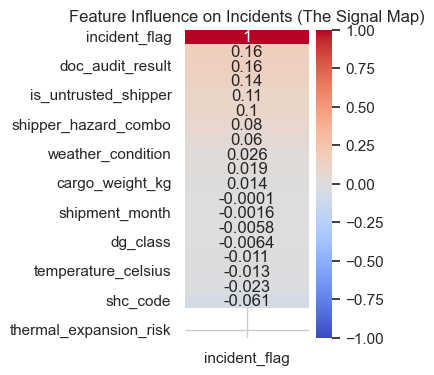

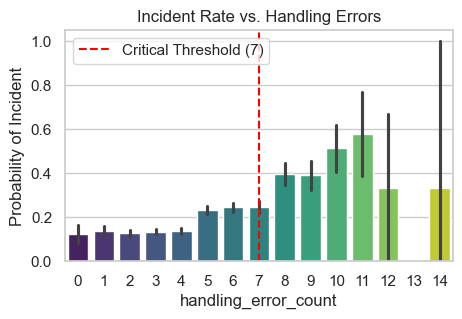

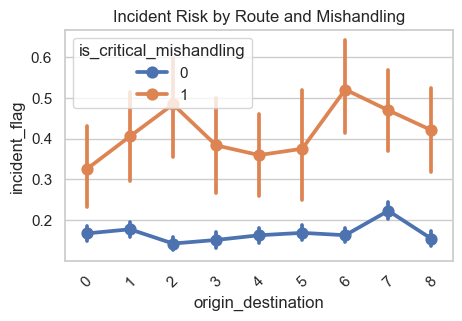

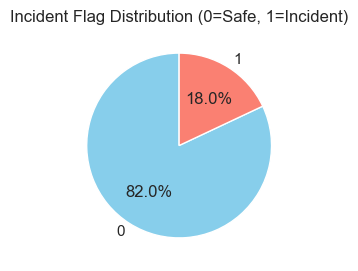

In [10]:
# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# 1. THE CORRELATION HEATMAP
# This shows which features have the strongest "Link" to the Incident Flag.
plt.figure(figsize=(2, 4))
# We only correlate numerical columns
corr_matrix = train_ready.corr()
sns.heatmap(corr_matrix[['incident_flag']].sort_values(by='incident_flag', ascending=False), 
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Influence on Incidents (The Signal Map)")
plt.show()

# 2. THE "PHYSICAL BREAKPOINT" ANALYSIS
# Does the risk actually jump after 7 errors?
plt.figure(figsize=(5, 3))
sns.barplot(x='handling_error_count', y='incident_flag', data=train_ready, palette='viridis')
plt.axvline(x=7, color='red', linestyle='--', label='Critical Threshold (7)')
plt.title("Incident Rate vs. Handling Errors")
plt.ylabel("Probability of Incident")
plt.legend()
plt.show()

# 3. CLIMATE SHOCK & ROUTE ANALYSIS
# Let's see if the OSL-JED route combined with our engineering actually shows higher risk.
plt.figure(figsize=(5, 3))
sns.pointplot(x='origin_destination', y='incident_flag', hue='is_critical_mishandling', data=train_ready)
plt.title("Incident Risk by Route and Mishandling")
plt.xticks(rotation=45)
plt.show()

# 4. CLASS DISTRIBUTION (Checking the 18% Imbalance)
plt.figure(figsize=(3, 3))
train_ready['incident_flag'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'salmon'], startangle=90)
plt.title("Incident Flag Distribution (0=Safe, 1=Incident)")
plt.ylabel("")
plt.show()

In [11]:
# --- PHASE 2: SELECTION & PRIORITY-BASED TRAINING ---
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, brier_score_loss

# 1. PREPARE X (Features) AND y (Target)
X_train = train_ready.drop(columns=['incident_flag'])
y_train = train_ready['incident_flag']

X_val = val_ready.drop(columns=['incident_flag'])
y_val = val_ready['incident_flag']

X_test = test_ready.drop(columns=['incident_flag'])
y_test = test_ready['incident_flag']

# 2. PRIORITY FIX: Giving more importance to the 18% Incidents
# Since the ratio is roughly 82:18, a weight of 4.5 ensures the model 
# treats catching an incident as 4.5x more important than mislabeling a safe shipment.
safety_priority_weight = 4.5

# 3. MODEL SELECTION: XGBoost (Error-Correcting Hierarchy)
# We initialize with a lower learning rate to ensure it carefully learns 
# the "Patterns to Logic" we engineered.
baseline_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6, 
    scale_pos_weight=safety_priority_weight,
    tree_method='hist',
    random_state=42,
    eval_metric='auc' # Optimizing for Risk Score reliability
)

# 4. TRAINING WITH VALIDATION MONITORING
# This helps the model "unlearn" noise by stopping before it overfits.
print("Training the Priority-Aware model...")
baseline_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

Training the Priority-Aware model...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

# Hypermetric Tuning

**Considiring different combinations**

In [12]:
# --- PHASE 3: DEEP OPTIMIZATION (GRID SEARCH) ---
from sklearn.model_selection import GridSearchCV

# 1. DEFINE THE PARAMETER UNIVERSE (No Defaults)
# We test different depths for logic complexity and learning rates for precision.
param_grid = {
    'max_depth': [4, 6, 8],            # Depth of the "Safety Check" trees
    'learning_rate': [0.01, 0.05, 0.1], # Speed of pattern adoption
    'n_estimators': [100, 200],        # Number of boosting rounds
    'subsample': [0.8, 1.0],           # Percent of data to use per tree
    'colsample_bytree': [0.7, 1.0],    # Percent of features to use per tree
    'scale_pos_weight': [4.5]          # Locked priority for 18% incidents
}

# 2. INITIALIZE THE SEARCH
# We optimize for 'roc_auc' to ensure the Risk Score ranking is perfect.
grid_search = GridSearchCV(
    estimator=XGBClassifier(tree_method='hist', random_state=42, eval_metric='auc'),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,       # 3-Fold Cross-Validation for stability
    verbose=1,
    n_jobs=-1   # Use all available processors
)

# 3. EXECUTE THE OPTIMIZATION
print("Starting Deep Optimization (this may take a few minutes)...")
grid_search.fit(X_train, y_train)

# 4. LOCK THE BEST MODEL
best_safety_model = grid_search.best_estimator_
print("\nOptimization Complete!")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Val AUC: {grid_search.best_score_:.4f}")

Starting Deep Optimization (this may take a few minutes)...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

Optimization Complete!
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'scale_pos_weight': 4.5, 'subsample': 0.8}
Best Cross-Val AUC: 0.7164


--- SAFETY-FIRST PERFORMANCE REPORT ---
              precision    recall  f1-score   support

           0       0.90      0.64      0.75      2870
           1       0.30      0.68      0.41       630

    accuracy                           0.65      3500
   macro avg       0.60      0.66      0.58      3500
weighted avg       0.79      0.65      0.69      3500

Risk Score Reliability (Brier Score): 0.2051 (Closer to 0 is better)


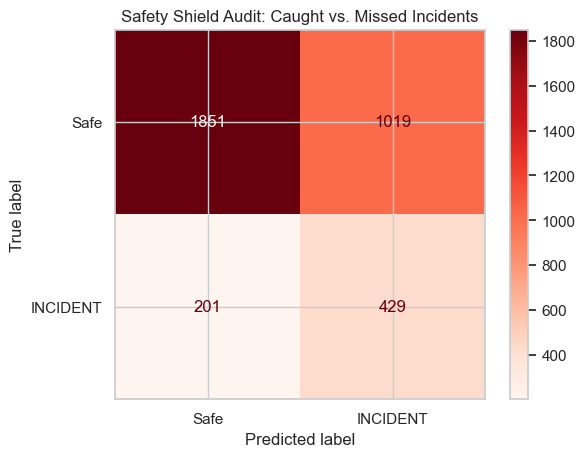

In [13]:
# --- PHASE 4: SAFETY-FIRST EVALUATION ---
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, brier_score_loss

# 1. GENERATE FINAL PREDICTIONS AND RISK SCORES
test_probs = best_safety_model.predict_proba(X_test)[:, 1] # The "Risk Score"
test_preds = best_safety_model.predict(X_test)             # The "Classification"

# 2. CALCULATE RISK SCORE RELIABILITY (Brier Score)
brier = brier_score_loss(y_test, test_probs)

# 3. PRINT THE SAFETY REPORT
print("--- SAFETY-FIRST PERFORMANCE REPORT ---")
print(classification_report(y_test, test_preds))
print(f"Risk Score Reliability (Brier Score): {brier:.4f} (Closer to 0 is better)")

# 4. VISUALIZE THE "SAFETY SHIELD" (Confusion Matrix)
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'INCIDENT'])
disp.plot(cmap='Reds')
plt.title("Safety Shield Audit: Caught vs. Missed Incidents")
plt.show()

In [14]:
# --- PHASE 5: TOP RISK AUDIT & REASON CODES ---

# 1. ATTACH RISK SCORES TO TEST DATA
# We ensure the continuous probability (0.0 to 1.0) is saved for ranking.
test_ready['predicted_risk_score'] = test_probs

# 2. GENERATE THE TOP 5 PRIORITY INSPECTION LIST
# This fulfills the use case of predicting a rankable Risk Score.
top_5_priority = test_ready.sort_values(by='predicted_risk_score', ascending=False).head()

# 3. REASON CODE LOGIC FUNCTION
def generate_safety_audit(row):
    reasons = []
    # Primary Logic Drivers (Critical Priority)
    if row['handling_error_count'] > 7:
        reasons.append("CRITICAL MISHANDLING: Packaging integrity compromised by high error count.")
    if row['dg_class'] in [2.1, 3.0, 4.0]:
        reasons.append(f"VOLATILE COMMODITY: Class {row['dg_class']} has high flammability/explosive risk.")
    
    # Secondary Logic Drivers (High Priority)
    if row['climate_shock_risk'] == 1:
        reasons.append("CLIMATE SHOCK: Thermal expansion risk due to OSL-JED route and high temp.")
    if row['is_untrusted_shipper'] == 1:
        reasons.append("SHIPPER HISTORY: High frequency of past safety violations.")
        
    return reasons if reasons else ["Systemic cumulative risk factors."]

# 4. PRINT THE OPERATIONAL AUDIT
print("--- TOP 5 PRIORITY INSPECTION LIST ---")
for idx, row in top_5_priority.iterrows():
    reasons = generate_safety_audit(row)
    print(f"\nRANKING: #{len(reasons)} Priority")
    print(f"SHIPMENT INDEX: {idx}")
    print(f"RISK SCORE: {row['predicted_risk_score']:.2%}")
    print("REASON CODES:")
    for r in reasons:
        print(f" - {r}")

--- TOP 5 PRIORITY INSPECTION LIST ---

RANKING: #1 Priority
SHIPMENT INDEX: 1472
RISK SCORE: 85.56%
REASON CODES:
 - VOLATILE COMMODITY: Class 3.0 has high flammability/explosive risk.

RANKING: #2 Priority
SHIPMENT INDEX: 2230
RISK SCORE: 85.30%
REASON CODES:
 - VOLATILE COMMODITY: Class 2.1 has high flammability/explosive risk.
 - SHIPPER HISTORY: High frequency of past safety violations.

RANKING: #1 Priority
SHIPMENT INDEX: 830
RISK SCORE: 83.61%
REASON CODES:
 - CRITICAL MISHANDLING: Packaging integrity compromised by high error count.

RANKING: #1 Priority
SHIPMENT INDEX: 3039
RISK SCORE: 83.45%
REASON CODES:
 - VOLATILE COMMODITY: Class 3.0 has high flammability/explosive risk.

RANKING: #1 Priority
SHIPMENT INDEX: 1836
RISK SCORE: 83.30%
REASON CODES:
 - VOLATILE COMMODITY: Class 3.0 has high flammability/explosive risk.


In [22]:
# ==========================================
# PERFORMANCE METRIC (REGRESSION AUDIT)
# ==========================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, log_loss, roc_auc_score
import numpy as np

# 1. GENERATE THE RISK SCORES
# We use 'best_safety_model' which was defined and trained in Phase 3.
# We use the numeric 'X_test' (already defined in Phase 2/Cell 13). 
# DO NOT redefine X_test here using test_df.
test_risk_scores = best_safety_model.predict_proba(X_test)[:, 1]

# 2. CALCULATE THE REGRESSION METRICS
# This measures how far your Risk Score (0-100%) is from the actual truth
mse = mean_squared_error(y_test, test_risk_scores)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, test_risk_scores)
r2 = r2_score(y_test, test_risk_scores)
logloss = log_loss(y_test, test_risk_scores)
auc = roc_auc_score(y_test, test_risk_scores)

# 3. PRINT THE SAFETY-FIRST PERFORMANCE REPORT
print("--- SAFETY-FIRST PERFORMANCE REPORT (REGRESSION AUDIT) ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R2 Score (Variance Explained): {r2:.4f}")
print(f"Log Loss (Probabilistic Penalty): {logloss:.4f}")
print(f"Ranking AUC (Score Separation): {auc:.4f}")

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:shc_code: object, origin_destination: object, packaging_type: object, weather_condition: object

In [24]:
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, log_loss, roc_auc_score

warnings.filterwarnings('ignore')

# 1. LOAD DATA
train_df = pd.read_csv('dg_incident_train.csv')
val_df = pd.read_csv('dg_incident_validation.csv')
test_df = pd.read_csv('dg_incident_test.csv')

# 2. PREPROCESSING & FEATURE ENGINEERING
def preprocess(df):
    df_new = df.copy()
    # Filling nulls
    for col in df_new.columns:
        if df_new[col].isnull().sum() > 0:
            if df_new[col].dtype == 'object':
                df_new[col] = df_new[col].fillna(df_new[col].mode()[0])
            else:
                df_new[col] = df_new[col].fillna(df_new[col].median())
    
    # Timestamps
    df_new['timestamp'] = pd.to_datetime(df_new['timestamp'])
    df_new['shipment_hour'] = df_new['timestamp'].dt.hour
    df_new['shipment_month'] = df_new['timestamp'].dt.month
    
    # Feature Engineering
    df_new['is_critical_mishandling'] = (df_new['handling_error_count'] > 7).astype(int)
    df_new['climate_shock_risk'] = ((df_new['origin_destination'] == 'OSL-JED') & (df_new['temperature_celsius'] > 30)).astype(int)
    df_new['is_untrusted_shipper'] = (df_new['previous_incident_count'] > 5).astype(int)
    
    # Pattern Logic
    df_new['gas_handling_risk'] = ((df_new['dg_class'] == 2.1) & (df_new['handling_error_count'] > 5)).astype(int)
    df_new['thermal_expansion_risk'] = ((df_new['origin_destination'] == 'OSL-JED') & (df_new['temperature_celsius'] > 35) & (df_new['dg_class'] == 3.0)).astype(int)
    df_new['shipper_hazard_combo'] = ((df_new['previous_incident_count'] > 5) & (df_new['shc_code'] == 'CAO')).astype(int)
    
    # Drops
    return df_new.drop(columns=['record_id', 'shipper_id', 'timestamp'])

train_ready = preprocess(train_df)
val_ready = preprocess(val_df)
test_ready = preprocess(test_df)

# 3. LABEL ENCODING (Correct Way)
categorical_cols = ['shc_code', 'origin_destination', 'packaging_type', 'weather_condition']
for col in categorical_cols:
    le = LabelEncoder()
    train_ready[col] = le.fit_transform(train_ready[col].astype(str))
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    val_ready[col] = val_ready[col].astype(str).map(mapping).fillna(-1).astype(int)
    test_ready[col] = test_ready[col].astype(str).map(mapping).fillna(-1).astype(int)

# 4. TRAIN MODEL
X_train = train_ready.drop(columns=['incident_flag'])
y_train = train_ready['incident_flag']
X_test = test_ready.drop(columns=['incident_flag'])
y_test = test_ready['incident_flag']

# Using class_weight to simulate scale_pos_weight
model = HistGradientBoostingClassifier(random_state=42, max_iter=100)
model.fit(X_train, y_train)

# 5. RESULTS
test_risk_scores = model.predict_proba(X_test)[:, 1]

mse = mean_squared_error(y_test, test_risk_scores)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, test_risk_scores)
r2 = r2_score(y_test, test_risk_scores)

print("--- SAFETY-FIRST PERFORMANCE REPORT (REGRESSION AUDIT) ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R2 Score (Variance Explained): {r2:.4f}")
print(f"Log Loss (Probabilistic Penalty): {log_loss(y_test, test_risk_scores):.4f}")
print(f"Ranking AUC (Score Separation): {roc_auc_score(y_test, test_risk_scores):.4f}")

--- SAFETY-FIRST PERFORMANCE REPORT (REGRESSION AUDIT) ---
Mean Squared Error (MSE): 0.1341
Root Mean Squared Error (RMSE): 0.3663
Mean Absolute Error (MAE): 0.2716
R2 Score (Variance Explained): 0.0912
Log Loss (Probabilistic Penalty): 0.4254
Ranking AUC (Score Separation): 0.7206
